In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("ecommerce_customers_unit1.csv")
df1 = df['country']
df

,customer_id,age,gender,country,signup_date,last_purchase_date,num_orders,total_spent,avg_order_value,recency_days,is_premium_member,device_type,preferred_category,churned
0,10001,56.0,Male,India,2022-01-27,2024-04-27,10,13273.25,1327.32,522,0,NaN,Home,0
1,10002,69.0,Other,UK,2025-01-12,2025-08-01,10,NaN,308.90,61,0,Mobile,Grocery,0
2,10003,46.0,Female,USA,2021-04-25,2021-06-01,5,3411.83,682.37,1583,0,NaN,NaN,0
3,10004,32.0,Male,India,2021-02-23,2023-09-22,5,4502.00,900.40,740,0,NaN,NaN,0
4,10005,60.0,Female,India,2021-06-07,2021-12-11,7,3842.10,548.87,1390,0,Tablet,Books,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
600,10358,25.0,Female,India,2023-09-04,2025-06-18,7,NaN,0.00,105,1,Mobile,Electronics,0
601,10117,50.0,Male,USA,2024-05-11,2024-11-08,4,3640.07,910.02,327,0,Mobile,Electronics,0
602,10599,46.0,Male,India,2020-12-01,2024-06-25,6,2176.22,362.70,463,1,Desktop,Electronics,0
603,10442,32.0,Female,UK,2023-12-20,2024-09-20,3,5478.65,1826.22,376,0,Mobile,Home,0


In [3]:
df.columns

Index(['customer_id', 'age', 'gender', 'country', 'signup_date',
       'last_purchase_date', 'num_orders', 'total_spent', 'avg_order_value',
       'recency_days', 'is_premium_member', 'device_type',
       'preferred_category', 'churned'],
      dtype='object')

In [4]:
df.shape

(605, 14)

In [5]:
df.isnull().sum()

customer_id            0
age                   28
gender                34
country               32
signup_date            0
last_purchase_date     0
num_orders             0
total_spent           34
avg_order_value        0
recency_days           0
is_premium_member      0
device_type           30
preferred_category    22
churned                0
dtype: int64

In [6]:
df.isnull().sum().sort_values()

customer_id            0
signup_date            0
last_purchase_date     0
num_orders             0
avg_order_value        0
recency_days           0
is_premium_member      0
churned                0
preferred_category    22
age                   28
device_type           30
country               32
gender                34
total_spent           34
dtype: int64

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'gender'),
  Text(1, 0, 'total_spent'),
  Text(2, 0, 'country'),
  Text(3, 0, 'device_type'),
  Text(4, 0, 'age'),
  Text(5, 0, 'preferred_category'),
  Text(6, 0, 'customer_id'),
  Text(7, 0, 'signup_date'),
  Text(8, 0, 'last_purchase_date'),
  Text(9, 0, 'num_orders'),
  Text(10, 0, 'avg_order_value'),
  Text(11, 0, 'recency_days'),
  Text(12, 0, 'is_premium_member'),
  Text(13, 0, 'churned')])

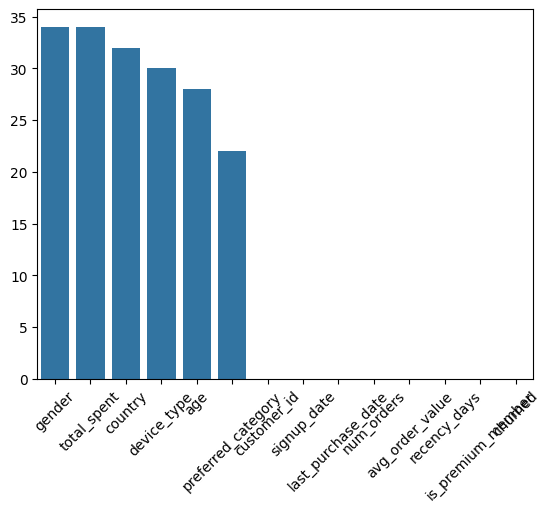

In [7]:
sns.barplot(df.isnull().sum().sort_values(ascending = False))
#missing_counts.plot(kind='bar') , here missing_counts is the variable having missing_counts = df.isnull().sum().sort_values()
plt.xticks(rotation=45)

In [8]:
df1 = df.select_dtypes(include='number')
df1

,customer_id,age,num_orders,total_spent,avg_order_value,recency_days,is_premium_member,churned
0,10001,56.0,10,13273.25,1327.32,522,0,0
1,10002,69.0,10,NaN,308.90,61,0,0
2,10003,46.0,5,3411.83,682.37,1583,0,0
3,10004,32.0,5,4502.00,900.40,740,0,0
4,10005,60.0,7,3842.10,548.87,1390,0,0
...,...,...,...,...,...,...,...,...
600,10358,25.0,7,NaN,0.00,105,1,0
601,10117,50.0,4,3640.07,910.02,327,0,0
602,10599,46.0,6,2176.22,362.70,463,1,0
603,10442,32.0,3,5478.65,1826.22,376,0,0


In [9]:
df['age'] = df['age'].fillna(df['age'].mean())
df['age']

0      56.0
1      69.0
2      46.0
3      32.0
4      60.0
       ... 
600    25.0
601    50.0
602    46.0
603    32.0
604    44.0
Name: age, Length: 605, dtype: float64

In [10]:
q1 = df['age'].quantile(0.25)
q3 = df['age'].quantile(0.75)
iqr = q3-q1
LB = q1 - 1.5*iqr
UB = q3 + 1.5*iqr
outliers = df[(df['age']<LB) | (df['age']>UB)]
print(f"The Number of outliers in age column are : {len(outliers)}")

The Number of outliers in age column are : 0


In [11]:
q1 = df['avg_order_value'].quantile(0.25)
q3 = df['avg_order_value'].quantile(0.75)
iqr = q3-q1
LB = q1 - 1.5*iqr
UB = q3 + 1.5*iqr
outliers = df[(df['avg_order_value']<LB) | (df['avg_order_value']>UB)]
print(f"The Number of Outliers in avg_order_value column are : {len(outliers)}")

The Number of Outliers in avg_order_value column are : 15


In [12]:
                                                                #FEATURE SCALING
#Normalization -> using Min Max Scaling

print(min(df['age']))
print(max(df['age']))
age_min = min(df['age'])
age_max = max(df['age'])

df['age'] = (df['age'] - age_min)/(age_max - age_min)
df['age']

18.0
69.0


0      0.745098
1      1.000000
2      0.549020
3      0.274510
4      0.823529
         ...   
600    0.137255
601    0.627451
602    0.549020
603    0.274510
604    0.509804
Name: age, Length: 605, dtype: float64

In [13]:
#Standardization-> using Standard Scaling (Z-Score Scaling)

order_mean = df['num_orders'].mean()
order_std = df['num_orders'].std()
print(order_mean)
print(order_std)

df['num_orders'] = (df['num_orders'] - order_mean) / order_std
df['num_orders']

5.945454545454545
2.332891790452413


0      1.737991
1      1.737991
2     -0.405271
3     -0.405271
4      0.452034
         ...   
600    0.452034
601   -0.833924
602    0.023381
603   -1.262577
604    0.023381
Name: num_orders, Length: 605, dtype: float64

In [14]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler

data = {
    'Age' : [18,22,45,60,80],
    'Income' : [2000,3000,10000,40000,80000]
}

df = pd.DataFrame(data)

# Normalization
norm = MinMaxScaler()
df_norm = pd.DataFrame(norm.fit_transform(df),columns=df.columns)

#Standardization
std = StandardScaler()
df_std = pd.DataFrame(std.fit_transform(df),columns = df.columns)

print("Original : \n",df)
print('\nNormalized : \n',df_norm)
print('\nStandardized : \n',df_std)

Original : 
    Age  Income
0   18    2000
1   22    3000
2   45   10000
3   60   40000
4   80   80000

Normalized : 
         Age    Income
0  0.000000  0.000000
1  0.064516  0.012821
2  0.435484  0.102564
3  0.677419  0.487179
4  1.000000  1.000000

Standardized : 
         Age    Income
0 -1.160177 -0.836312
1 -0.988299 -0.802860
2  0.000000 -0.568692
3  0.644543  0.434882
4  1.503934  1.772982
